# Quantum Fourier Transform — IBM Quantum Hardware Version

This notebook converts the QFT simulator example into a real-hardware experiment using IBM Quantum. It is designed to document how well ChatGPT can extend a simulator-based Qiskit notebook into hardware execution.

The direct QFT of `|101⟩` is not a good hardware histogram test because it produces a superposition. The hardware-comparable experiment prepares `|~5⟩`, applies inverse QFT, and measures. The expected dominant bitstring is `101`, with extra bitstrings caused by hardware noise.

## Research log fields

Fill these in while testing ChatGPT's generated hardware workflow:

| Field | Notes |
|---|---|
| Algorithm | Quantum Fourier Transform / inverse QFT verification |
| Qubits | 3 initially; later scale to 4, 5, 6, 7 if possible |
| Expected hardware target | dominant `101` for 3-qubit version |
| Backend used |  |
| Shots | 4096 by default |
| Did ChatGPT code run immediately? |  |
| Fixes needed |  |
| Outdated syntax? |  |
| Bit-ordering or measurement confusion? |  |
| Did hardware match simulator? |  |
| Noise impact |  |

In [ ]:
# Install dependencies if needed. In Google Colab, run this once.
%pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
from numpy import pi

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

## IBM Quantum account setup

Use **one** of the following approaches:

1. If your IBM account is already saved in the environment, run `service = QiskitRuntimeService()`.
2. If not saved, uncomment the `save_account` line and paste your token once. Do **not** submit or share notebooks containing your API token.

In [ ]:
# OPTION A: Use an already saved IBM Quantum account
service = QiskitRuntimeService()

# OPTION B: Save your token once, then comment this out afterwards
# QiskitRuntimeService.save_account(
#     channel='ibm_quantum',
#     token='PASTE_YOUR_IBM_QUANTUM_API_TOKEN_HERE',
#     overwrite=True
# )
# service = QiskitRuntimeService()

In [ ]:
QiskitRuntimeService.save_account(
     channel='ibm_quantum_platform',
     token='',
     overwrite=True
 )
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-06-30 21:43:26,448: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


## QFT helper functions

These preserve the same logic as the course notebook. This is important for the research comparison because the hardware version should not quietly change the original algorithm.

In [ ]:
def qft_rotations(circuit, n):
    """Apply QFT rotations on the first n qubits, without final swaps."""
    if n == 0:
        return circuit
    n -= 1
    circuit.h(n)
    for qubit in range(n):
        circuit.cp(pi / 2**(n - qubit), qubit, n)
    qft_rotations(circuit, n)
    return circuit


def swap_registers(circuit, n):
    """Swap qubits to match the conventional QFT output order."""
    for qubit in range(n // 2):
        circuit.swap(qubit, n - qubit - 1)
    return circuit


def qft(circuit, n):
    """Apply QFT on the first n qubits of circuit."""
    qft_rotations(circuit, n)
    swap_registers(circuit, n)
    return circuit


def inverse_qft(circuit, n):
    """Append inverse QFT to the first n qubits of circuit."""
    qft_circ = qft(QuantumCircuit(n), n)
    invqft_circ = qft_circ.inverse()
    circuit.append(invqft_circ, circuit.qubits[:n])
    return circuit.decompose()


def prepare_fourier_state(number, nqubits):
    """Prepare the Fourier-basis state |~number> for nqubits.

    Generalized from the course notebook's 3-qubit |~5> example.
    """
    qc = QuantumCircuit(nqubits)
    for qubit in range(nqubits):
        qc.h(qubit)
    for qubit in range(nqubits):
        qc.p(number * pi / 2**(nqubits - 1 - qubit), qubit)
    return qc

## Build the 3-qubit hardware circuit

Expected result: dominant `101`.

Important documentation point: QFT has a known output-order issue, and Qiskit bitstrings can also be confusing. If the hardware result appears as `101`, `101` is directly consistent with the simulator version here. If a reversed-looking bitstring appears, document whether the issue is noise, swap placement, or bit-order interpretation.

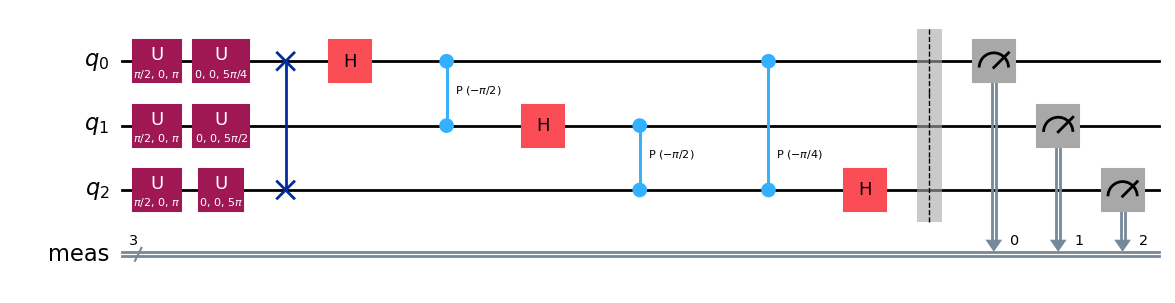

In [ ]:
nqubits = 3
number = 5
shots = 4096

qc_hw = prepare_fourier_state(number, nqubits)
qc_hw = inverse_qft(qc_hw, nqubits)
qc_hw.measure_all()

qc_hw.draw('mpl')

In [ ]:
# Select a real device with enough qubits. You can also set a backend manually:
# backend = service.backend('ibm_brisbane')

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=nqubits)
print('Selected backend:', backend.name)

qiskit_runtime_service.backends:WARNING:2026-06-30 21:43:58,739: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 21:44:02,784: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


Original circuit depth: 10
Transpiled circuit depth: 32
Transpiled operation counts: OrderedDict({'sx': 18, 'rz': 16, 'cz': 7, 'measure': 3, 'x': 1, 'barrier': 1})


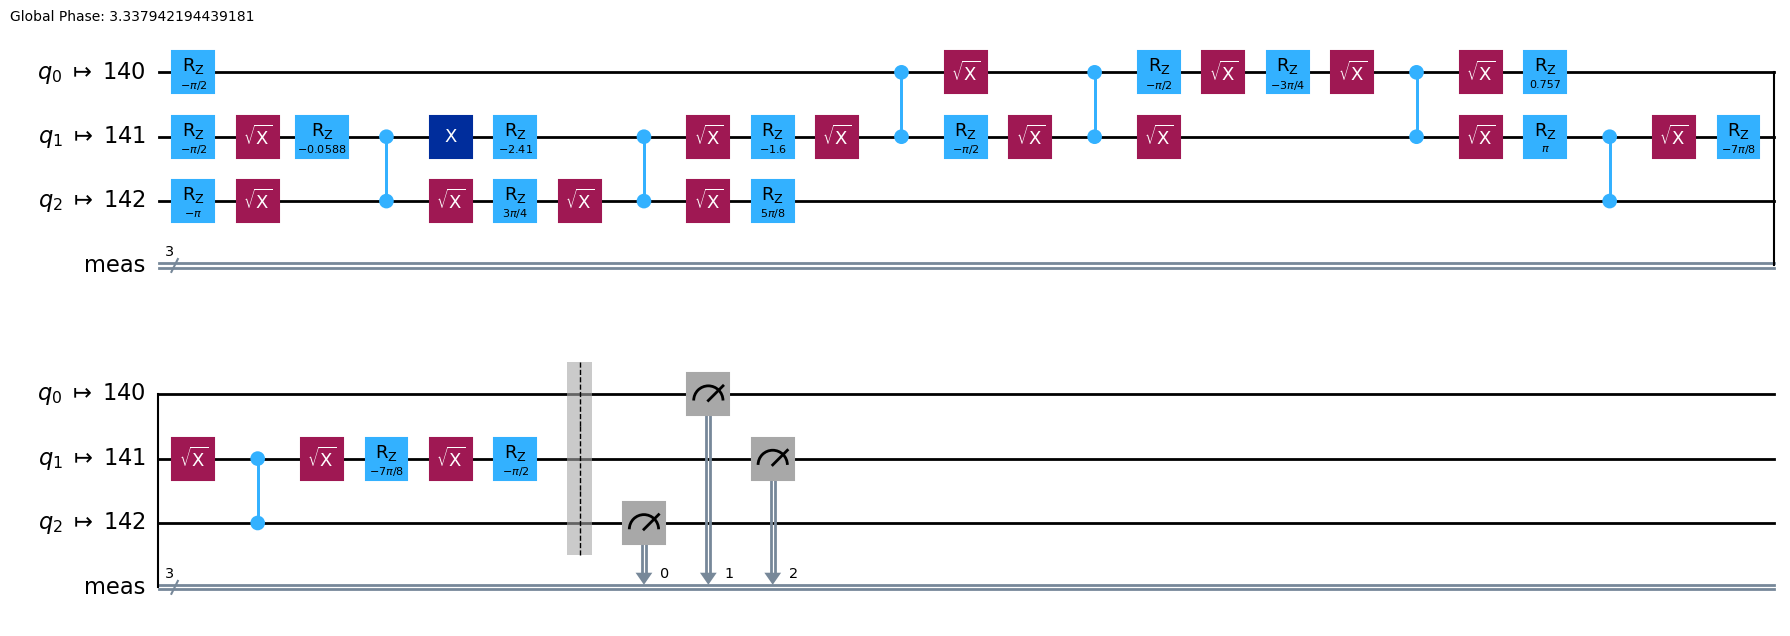

In [ ]:
# Transpile for the selected hardware.
# Keep optimization_level visible because transpilation may affect circuit depth and noise.
transpiled_qc = transpile(qc_hw, backend=backend, optimization_level=3, seed_transpiler=42)

print('Original circuit depth:', qc_hw.depth())
print('Transpiled circuit depth:', transpiled_qc.depth())
print('Transpiled operation counts:', transpiled_qc.count_ops())

transpiled_qc.draw('mpl', idle_wires=False)

In [ ]:
# Run on IBM Quantum hardware using SamplerV2.
# This follows the current V2 primitive workflow: sampler.run([circuit], shots=shots).

sampler = Sampler(mode=backend)
job = sampler.run([transpiled_qc], shots=shots)
print('Job ID:', job.job_id())

Job ID: d923hb7ccmks73d64ud0


Hardware counts: {'101': 3709, '010': 21, '100': 224, '011': 23, '000': 33, '111': 24, '110': 31, '001': 31}
Dominant hardware bitstring: 101


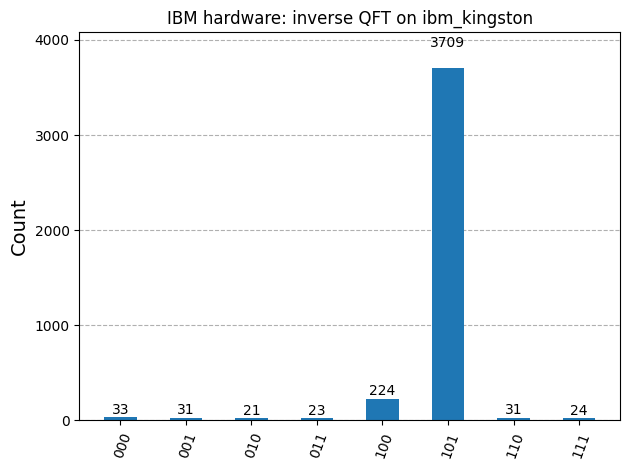

In [ ]:
# Retrieve results.
# SamplerV2 returns a PubResult. With measure_all(), the classical register is usually named 'meas'.

result = job.result()
pub_result = result[0]

try:
    counts_hw = pub_result.data.meas.get_counts()
except Exception:
    # More robust fallback if the classical register is named differently.
    counts_hw = None
    for field_name in dir(pub_result.data):
        if field_name.startswith('_'):
            continue
        field = getattr(pub_result.data, field_name)
        if hasattr(field, 'get_counts'):
            counts_hw = field.get_counts()
            print(f'Counts extracted from classical register: {field_name}')
            break
    if counts_hw is None:
        raise RuntimeError('Could not extract counts. Inspect pub_result.data to find the classical register name.')

print('Hardware counts:', counts_hw)
print('Dominant hardware bitstring:', max(counts_hw, key=counts_hw.get))
plot_histogram(counts_hw, title=f'IBM hardware: inverse QFT on {backend.name}')

## Comparison notes to fill in

Use this after running the notebook:

| Check | Result |
|---|---|
| Expected dominant bitstring | `101` |
| Actual dominant bitstring |  |
| Percentage of dominant bitstring |  |
| Main noisy outputs |  |
| Does the hardware result still meaningfully match simulator? |  |
| Any ChatGPT mistakes or confusion? |  |

Possible minor issues to document:

- ChatGPT gives old `execute()` / `backend.run()` code instead of Runtime SamplerV2.
- ChatGPT forgets that direct QFT measurement is not a clear hardware validation.
- ChatGPT reverses the bitstring interpretation.
- ChatGPT changes the circuit instead of preserving the course notebook logic.
- ChatGPT does not mention that deeper controlled-phase circuits may become noisy when scaled.

## Optional scaling experiment

After the 3-qubit case, increase `nqubits` and choose `number = 2**nqubits - 3`, or another known integer. The expected bitstring should be `format(number, f"0{nqubits}b")`.

Suggested sequence: 3, 4, 5, 6, 7 qubits.

Track when the dominant result becomes unclear.

Expected dominant bitstring: 0101


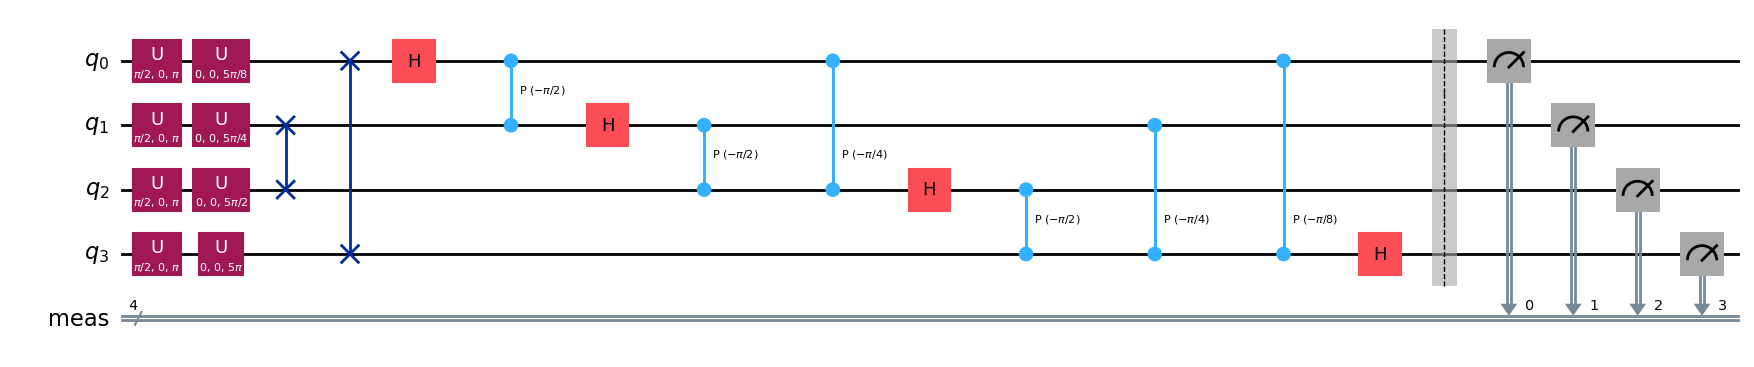

In [ ]:
def build_inverse_qft_test_circuit(nqubits, number):
    qc = prepare_fourier_state(number, nqubits)
    qc = inverse_qft(qc, nqubits)
    qc.measure_all()
    return qc

# Example scaling setup. Uncomment and run after finishing the 3-qubit baseline.
nqubits = 4
number = 5
expected = format(number, f'0{nqubits}b')
qc_scaled = build_inverse_qft_test_circuit(nqubits, number)
print('Expected dominant bitstring:', expected)
qc_scaled.draw('mpl')